# SentinelVision AI
## Notebook 03 — Feature Extraction

### Objective

Notebook 01 analyzed dataset metadata.

Notebook 02 inspected the real video content.

This notebook converts video clips into reusable numeric embeddings.

The goal is to create one feature vector per clip so later anomaly models can train without repeatedly decoding raw video.

The flow is:

`clip manifest → frame sampling → resize frames → frame features → clip embeddings → saved embedding table`

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

c:\Users\tevin\OneDrive\Desktop\Computer-Vision\SentinelVision-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We are still not modeling.

We are turning raw video into structured model-ready data.

In [2]:
metadata_dir = Path("../data/metadata")
embeddings_dir = Path("../data/embeddings")

embeddings_dir.mkdir(
    parents=True,
    exist_ok=True,
)

clip_manifest = pd.read_parquet(
    metadata_dir / "clip_manifest.parquet"
)

clip_manifest.shape

(44996, 12)

In [3]:
clip_manifest.head()

,clip_id,video_id,file_path,category,binary_label,split,clip_index,start_seconds,end_seconds,clip_duration_seconds,source_video_duration_seconds,source_fps
0,Abuse002_x264_clip_00000,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,0,0.0,4.0,4.0,28.833,30.0
1,Abuse002_x264_clip_00001,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,1,4.0,8.0,4.0,28.833,30.0
2,Abuse002_x264_clip_00002,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,2,8.0,12.0,4.0,28.833,30.0
3,Abuse002_x264_clip_00003,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,3,12.0,16.0,4.0,28.833,30.0
4,Abuse002_x264_clip_00004,Abuse002_x264,data\raw\ucf-crime\Anomaly-Videos-Part-1\Anoma...,Abuse,1,test,4,16.0,20.0,4.0,28.833,30.0


#### Resolve video paths

In [4]:
project_root = Path("..").resolve()


def resolve_video_path(file_path: str) -> Path:
    """
    Convert a stored video path into an absolute path.
    """
    path = Path(file_path)

    if path.is_absolute():
        return path

    return project_root / path

In [5]:
example_path = resolve_video_path(
    clip_manifest.iloc[0]["file_path"]
)

print(example_path)
print("Exists:", example_path.exists())

C:\Users\tevin\OneDrive\Desktop\Computer-Vision\SentinelVision-AI\data\raw\ucf-crime\Anomaly-Videos-Part-1\Anomaly-Videos-Part-1\Abuse\Abuse002_x264.mp4
Exists: True


#### Create a small extraction sample

In [6]:
sample_size = 500

clip_sample = (
    clip_manifest
    .groupby("split", group_keys=False)
    .apply(
        lambda group: group.sample(
            n=min(len(group), sample_size // 3),
            random_state=42,
        )
    )
    .reset_index(drop=True)
)

clip_sample.shape

C:\Users\tevin\AppData\Local\Temp\ipykernel_11168\1720202967.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


(498, 12)

In [8]:
clip_sample["split"].value_counts()

split
test          166
train         166
validation    166
Name: count, dtype: int64

#### Frame sampling function

In [9]:
def read_frame_at_time(
    video_path: str | Path,
    timestamp_seconds: float,
) -> np.ndarray | None:
    """
    Read one RGB frame from a video at a specific timestamp.
    """
    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        capture.release()
        return None

    capture.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp_seconds * 1000,
    )

    success, frame = capture.read()
    capture.release()

    if not success or frame is None:
        return None

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    return frame_rgb

In [10]:
def sample_clip_frames(
    video_path: str | Path,
    start_seconds: float,
    end_seconds: float,
    number_of_frames: int = 8,
) -> list[np.ndarray]:
    """
    Sample evenly spaced frames from one clip window.
    """
    if end_seconds <= start_seconds:
        return []

    timestamps = np.linspace(
        start_seconds,
        max(end_seconds - 0.05, start_seconds),
        number_of_frames,
    )

    frames = []

    for timestamp in timestamps:
        frame = read_frame_at_time(
            video_path=video_path,
            timestamp_seconds=float(timestamp),
        )

        if frame is not None:
            frames.append(frame)

    return frames

#### Resize frames

In [11]:
def resize_frame(
    frame: np.ndarray,
    size: tuple[int, int] = (112, 112),
) -> np.ndarray:
    """
    Resize one RGB frame to a fixed spatial size.
    """
    resized = cv2.resize(
        frame,
        size,
        interpolation=cv2.INTER_AREA,
    )

    return resized

In [12]:
def preprocess_frames(
    frames: list[np.ndarray],
    size: tuple[int, int] = (112, 112),
) -> list[np.ndarray]:
    """
    Resize all frames in a clip.
    """
    return [
        resize_frame(frame, size=size)
        for frame in frames
    ]

#### Build simple frame features

In [13]:
def frame_to_features(frame: np.ndarray) -> np.ndarray:
    """
    Convert one RGB frame into simple numeric features.

    Features:
    - mean RGB values
    - standard deviation RGB values
    - grayscale brightness mean
    - grayscale brightness standard deviation
    """
    frame_float = frame.astype(np.float32) / 255.0

    rgb_mean = frame_float.mean(axis=(0, 1))
    rgb_std = frame_float.std(axis=(0, 1))

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_RGB2GRAY,
    ).astype(np.float32) / 255.0

    gray_mean = np.array([gray.mean()])
    gray_std = np.array([gray.std()])

    features = np.concatenate(
        [
            rgb_mean,
            rgb_std,
            gray_mean,
            gray_std,
        ]
    )

    return features

#### Convert clip to embedding

In [14]:
def clip_to_embedding(
    video_path: str | Path,
    start_seconds: float,
    end_seconds: float,
    number_of_frames: int = 8,
    frame_size: tuple[int, int] = (112, 112),
) -> np.ndarray | None:
    """
    Convert one clip window into one numeric embedding.
    """
    frames = sample_clip_frames(
        video_path=video_path,
        start_seconds=start_seconds,
        end_seconds=end_seconds,
        number_of_frames=number_of_frames,
    )

    if not frames:
        return None

    processed_frames = preprocess_frames(
        frames=frames,
        size=frame_size,
    )

    frame_features = np.array(
        [
            frame_to_features(frame)
            for frame in processed_frames
        ]
    )

    # Aggregate frame-level features into one clip-level vector.
    clip_mean = frame_features.mean(axis=0)
    clip_std = frame_features.std(axis=0)

    clip_embedding = np.concatenate(
        [
            clip_mean,
            clip_std,
        ]
    )

    return clip_embedding

#### Test on one clip

In [15]:
test_clip = clip_sample.iloc[0]

test_video_path = resolve_video_path(
    test_clip["file_path"]
)

test_embedding = clip_to_embedding(
    video_path=test_video_path,
    start_seconds=test_clip["start_seconds"],
    end_seconds=test_clip["end_seconds"],
)

print("Embedding:", test_embedding)
print("Shape:", test_embedding.shape if test_embedding is not None else None)

Embedding: [4.16162938e-01 3.86835337e-01 3.74140859e-01 2.22728819e-01
 2.29553789e-01 2.37032130e-01 3.94131273e-01 2.25521579e-01
 2.68998643e-04 1.58456751e-04 2.36329724e-04 1.17858544e-04
 1.40403572e-04 2.04213196e-04 1.62341385e-04 8.69885043e-05]
Shape: (16,)


#### Extract embeddings for sample clips

In [18]:
embedding_records = []

for row in tqdm(
    clip_sample.itertuples(index=False),
    total=len(clip_sample),
    desc="Extracting clip embeddings",
):
    video_path = resolve_video_path(row.file_path)

    embedding = clip_to_embedding(
        video_path=video_path,
        start_seconds=row.start_seconds,
        end_seconds=row.end_seconds,
        number_of_frames=8,
        frame_size=(112, 112),
    )

    if embedding is None:
        continue

    record = {
        "clip_id": row.clip_id,
        "video_id": row.video_id,
        "category": row.category,
        "binary_label": row.binary_label,
        "split": row.split,
        "start_seconds": row.start_seconds,
        "end_seconds": row.end_seconds,
    }

    for index, value in enumerate(embedding):
        record[f"feature_{index:03d}"] = float(value)

    embedding_records.append(record)

embeddings = pd.DataFrame(embedding_records)

embeddings.shape

Extracting clip embeddings: 100%|██████████| 498/498 [03:46<00:00,  2.20it/s]


(498, 23)

In [19]:
embeddings.head()

,clip_id,video_id,category,binary_label,split,start_seconds,end_seconds,feature_000,feature_001,feature_002,...,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015
0,Shooting022_x264_clip_00010,Shooting022_x264,Shooting,1,test,40.0,44.0,0.416163,0.386835,0.374141,...,0.394131,0.225522,0.000269,0.000158,0.000236,0.000118,0.000140,0.000204,0.000162,0.000087
1,Vandalism041_x264_clip_00021,Vandalism041_x264,Vandalism,1,test,84.0,88.0,0.257803,0.171437,0.062419,...,0.184771,0.186079,0.002649,0.001979,0.000456,0.003085,0.002011,0.000281,0.001935,0.001966
2,Robbery130_x264_clip_00002,Robbery130_x264,Robbery,1,test,8.0,12.0,0.425955,0.425692,0.420834,...,0.425198,0.173660,0.003575,0.002963,0.002644,0.006365,0.006437,0.005010,0.003006,0.006305
3,Normal_Videos_641_x264_clip_00025,Normal_Videos_641_x264,Normal,0,test,100.0,104.0,0.289380,0.271774,0.224172,...,0.271585,0.246034,0.007098,0.005536,0.003933,0.000932,0.002951,0.001615,0.005603,0.002558
4,Abuse015_x264_clip_00012,Abuse015_x264,Abuse,1,test,48.0,52.0,0.503250,0.506105,0.498351,...,0.504288,0.403972,0.000653,0.000701,0.000608,0.000398,0.000426,0.000355,0.000664,0.000405


#### Check extraction coverage

In [20]:
requested_clips = len(clip_sample)
extracted_clips = len(embeddings)

coverage = extracted_clips / requested_clips

print(f"Requested clips: {requested_clips:,}")
print(f"Extracted clips: {extracted_clips:,}")
print(f"Coverage: {coverage:.2%}")

Requested clips: 498
Extracted clips: 498
Coverage: 100.00%


#### Inspect embedding columns

In [21]:
feature_columns = [
    column
    for column in embeddings.columns
    if column.startswith("feature_")
]

print("Number of feature columns:", len(feature_columns))
print(feature_columns[:10])

Number of feature columns: 16
['feature_000', 'feature_001', 'feature_002', 'feature_003', 'feature_004', 'feature_005', 'feature_006', 'feature_007', 'feature_008', 'feature_009']


In [22]:
embeddings[feature_columns].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
feature_000,498.0,0.354915,0.114595,2.669461e-02,0.284567,0.350387,0.426720,0.777973
feature_001,498.0,0.350218,0.112810,3.172464e-02,0.277490,0.350753,0.422343,0.767640
feature_002,498.0,0.344014,0.113054,2.183769e-02,0.269975,0.344338,0.420445,0.797984
feature_003,498.0,0.231836,0.056576,7.323213e-02,0.193667,0.230925,0.268995,0.428306
feature_004,498.0,0.229860,0.057166,7.446031e-02,0.187032,0.229460,0.268146,0.454655
feature_005,498.0,0.229566,0.058964,5.408868e-02,0.184903,0.228520,0.267907,0.452592
feature_006,498.0,0.350895,0.112518,3.128783e-02,0.278119,0.350406,0.424844,0.774023
feature_007,498.0,0.228643,0.056520,7.134102e-02,0.185121,0.228730,0.267420,0.440606
feature_008,498.0,0.008275,0.017292,9.513450e-07,0.001042,0.002930,0.007374,0.170211
feature_009,498.0,0.008373,0.019619,1.973914e-06,0.000941,0.002798,0.007087,0.198156


#### Save sample embeddings

In [23]:
sample_embeddings_path = (
    embeddings_dir / "clip_embeddings_sample.parquet"
)

embeddings.to_parquet(
    sample_embeddings_path,
    index=False,
)

sample_embeddings_path

WindowsPath('../data/embeddings/clip_embeddings_sample.parquet')

In [24]:
pd.read_parquet(sample_embeddings_path).head()

,clip_id,video_id,category,binary_label,split,start_seconds,end_seconds,feature_000,feature_001,feature_002,...,feature_006,feature_007,feature_008,feature_009,feature_010,feature_011,feature_012,feature_013,feature_014,feature_015
0,Shooting022_x264_clip_00010,Shooting022_x264,Shooting,1,test,40.0,44.0,0.416163,0.386835,0.374141,...,0.394131,0.225522,0.000269,0.000158,0.000236,0.000118,0.000140,0.000204,0.000162,0.000087
1,Vandalism041_x264_clip_00021,Vandalism041_x264,Vandalism,1,test,84.0,88.0,0.257803,0.171437,0.062419,...,0.184771,0.186079,0.002649,0.001979,0.000456,0.003085,0.002011,0.000281,0.001935,0.001966
2,Robbery130_x264_clip_00002,Robbery130_x264,Robbery,1,test,8.0,12.0,0.425955,0.425692,0.420834,...,0.425198,0.173660,0.003575,0.002963,0.002644,0.006365,0.006437,0.005010,0.003006,0.006305
3,Normal_Videos_641_x264_clip_00025,Normal_Videos_641_x264,Normal,0,test,100.0,104.0,0.289380,0.271774,0.224172,...,0.271585,0.246034,0.007098,0.005536,0.003933,0.000932,0.002951,0.001615,0.005603,0.002558
4,Abuse015_x264_clip_00012,Abuse015_x264,Abuse,1,test,48.0,52.0,0.503250,0.506105,0.498351,...,0.504288,0.403972,0.000653,0.000701,0.000608,0.000398,0.000426,0.000355,0.000664,0.000405


#### Quick visual check of embedding space

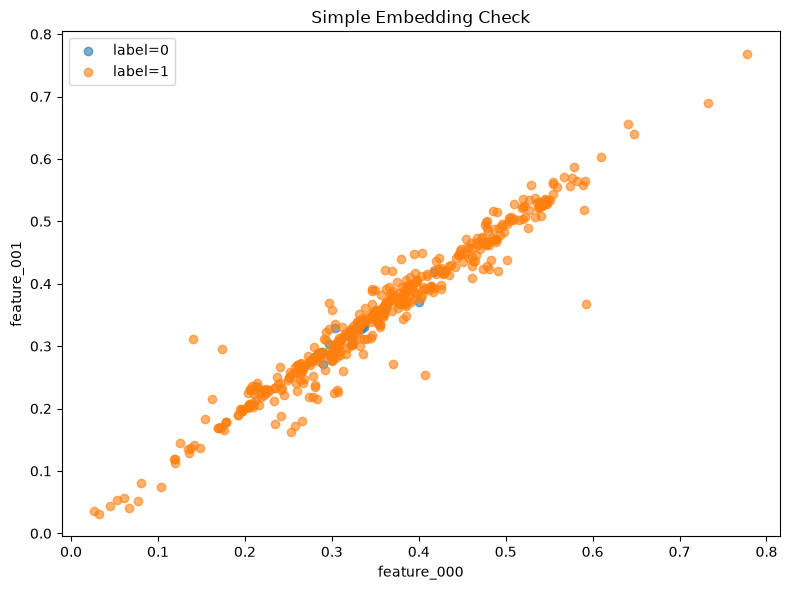

In [25]:
plt.figure(figsize=(8, 6))

for label in sorted(embeddings["binary_label"].unique()):
    subset = embeddings[
        embeddings["binary_label"] == label
    ]

    plt.scatter(
        subset["feature_000"],
        subset["feature_001"],
        label=f"label={label}",
        alpha=0.6,
    )

plt.title("Simple Embedding Check")
plt.xlabel("feature_000")
plt.ylabel("feature_001")
plt.legend()
plt.tight_layout()
plt.show()

# Conclusion

Notebook 03 created the first reusable feature table for SentinelVision AI.

## What was done

We:

- loaded the clip manifest,
- sampled a manageable subset of clips,
- read frames from real video files,
- resized frames to a consistent shape,
- extracted simple numeric frame features,
- aggregated frame features into clip embeddings,
- saved the result as a Parquet file.

## Output created

`data/embeddings/clip_embeddings_sample.parquet`

## Why this matters

The project now has model-ready data.

Instead of decoding videos repeatedly, later notebooks can load the saved embedding table directly.

## Important limitation

These are simple statistical visual embeddings, not deep pretrained video embeddings.

They are good enough for building the first anomaly-detection baseline.

Later, this feature extraction stage can be upgraded to pretrained CNN or video-model embeddings.

## Next notebook

Notebook 04 will train baseline anomaly models:

`clip embeddings → distance threshold baseline → Isolation Forest → evaluation`